In [1]:
from djchurchland.schema import Chipmunk

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from natsort import natsorted

new_rc_params = {"text.usetex": False, "svg.fonttype": "none"}
mpl.rcParams.update(new_rc_params)
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["font.size"] = 12

%matplotlib widget
%load_ext autoreload
%autoreload 2

[2025-10-08 14:31:42,544][INFO]: Connecting gabriel@localhost:3306
[2025-10-08 14:31:42,570][INFO]: Connected gabriel@localhost:3306


In [2]:
good_trials = (
    Chipmunk.Trial()
    & "subject_name = 'GRB006'"
    & "session_datetime LIKE '2024-07-23%'"
    & "with_choice = 1"
).fetch("trial_number")

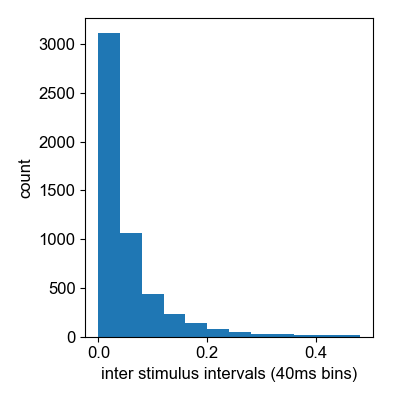

In [3]:
isi = np.hstack(
    (
        Chipmunk.TrialParameters()
        & "subject_name = 'GRB006'"
        & "session_datetime LIKE '2024-07-23%'"
        & f"trial_number IN {tuple(good_trials)}"
    ).fetch("inter_stim_intervals")
)
fig, ax = plt.subplots(1, figsize=(4, 4))
ax.hist(isi, bins=np.arange(0, 0.5, 0.04))
ax.set_xlabel("inter stimulus intervals (40ms bins)")
ax.set_ylabel("count")
fig.tight_layout()

In [4]:
stim_rate = (
    Chipmunk.TrialParameters()
    & "subject_name = 'GRB006'"
    & "session_datetime LIKE '2024-07-23%'"
    & f"trial_number IN {tuple(good_trials)}"
).fetch("stim_rate")

isi = (
    Chipmunk.TrialParameters()
    & "subject_name = 'GRB006'"
    & "session_datetime LIKE '2024-07-23%'"
    & f"trial_number IN {tuple(good_trials)}"
).fetch("inter_stim_intervals")

rewarded = (
    Chipmunk.Trial()
    & "subject_name = 'GRB006'"
    & "session_datetime LIKE '2024-07-23%'"
    & f"trial_number IN {tuple(good_trials)}"
).fetch("rewarded")

data = pd.DataFrame({"stim_rate": stim_rate, "isi": isi, "rewarded": rewarded})

In [5]:
grouped_isi = data.groupby("stim_rate")["isi"].apply(lambda x: np.hstack(x))

In [6]:
grouped_isi

stim_rate
4.0     [0.0, 0.625, 0.265, 0.025, 0.025, 0.0, 0.225, ...
5.0     [0.0, 0.225, 0.10500000000000001, 0.185, 0.105...
6.0     [0.0, 0.065, 0.185, 0.185, 0.145, 0.1050000000...
8.0     [0.0, 0.025, 0.065, 0.185, 0.065, 0.265, 0.025...
10.0    [0.0, 0.025, 0.025, 0.185, 0.10500000000000001...
12.0    [0.0, 0.065, 0.025, 0.10500000000000001, 0.145...
14.0    [0.0, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025...
16.0    [0.0, 0.025, 0.065, 0.025, 0.025, 0.025, 0.065...
18.0    [0.0, 0.065, 0.025, 0.065, 0.025, 0.065, 0.025...
19.0    [0.0, 0.025, 0.025, 0.025, 0.065, 0.025, 0.065...
20.0    [0.0, 0.10500000000000001, 0.025, 0.025, 0.025...
Name: isi, dtype: object

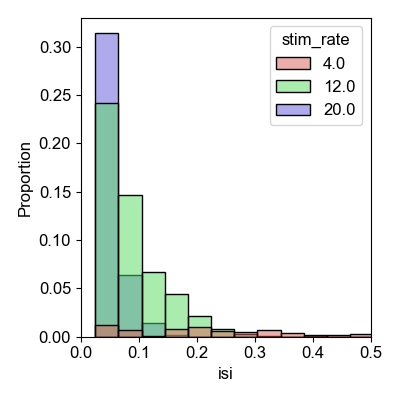

In [35]:
# Clean the exploded data for overall stimulus statistics
data_exploded = data.copy()
data_exploded = data_exploded.explode("isi")
data_exploded["isi"] = data_exploded["isi"].astype(float)

# Remove first ISIs (usually 0) and any very short artifacts
data_exploded = data_exploded[data_exploded["isi"] > 0.01]  # 10ms threshold

mask = data_exploded.stim_rate.isin([4, 12, 20])
data_exploded = data_exploded[mask]

pal = sns.color_palette("hls", n_colors=3)
fig, ax = plt.subplots(1, figsize=(4, 4))
sns.histplot(
    data=data_exploded,
    x="isi",
    hue="stim_rate",
    ax=ax,
    palette=pal,
    binwidth=0.04,
    stat="proportion",
)
ax.set_xlim([0, 0.5])
fig.tight_layout()

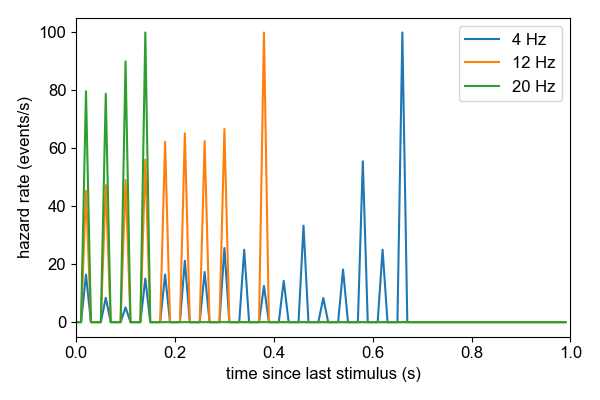

In [49]:
def compute_hazard_function(isi_sample, dt=0.01, max_time=1):
    """
    Compute hazard function for inter-stimulus intervals
    isi_sample: array of observed inter-stimulus intervals
    dt: time bin width
    max_time: maximum time to compute hazard
    """
    times = np.arange(0, max_time, dt)
    n_bins = len(times)

    # Count how many ISIs end in each time bin
    isi_counts, _ = np.histogram(isi_sample, bins=np.append(times, max_time))

    # Calculate number of ISI intervals still "at risk" at each time point
    # (ISI intervals that haven't ended yet - no stimulus delivered yet...)
    intervals_at_risk = len(isi_sample) - np.cumsum(
        np.concatenate([[0], isi_counts[:-1]])
    )

    # Compute instantaneous hazard rate:
    # (ISIs ending in this bin) / (ISIs still ongoing at start of bin * bin width)
    hazard_rate = np.zeros(n_bins)
    valid_bins = intervals_at_risk > 0
    hazard_rate[valid_bins] = isi_counts[valid_bins] / (
        intervals_at_risk[valid_bins] * dt
    )

    return times, hazard_rate


# Now your hazard analysis represents overall stimulus timing statistics
rates = [4, 12, 20]
fig, ax = plt.subplots(figsize=(6, 4))

for r in rates:
    sample = data_exploded.loc[data_exploded.stim_rate == r, "isi"].to_numpy()
    if sample.size == 0:
        continue
    times, hazard = compute_hazard_function(sample, dt=0.01, max_time=1)
    ax.plot(times, hazard, label=f"{r} Hz", linewidth=1.5)

ax.set_xlim(0, 1)
ax.set_xlabel("time since last stimulus (s)")
ax.set_ylabel("hazard rate (events/s)")
ax.legend()
fig.tight_layout()

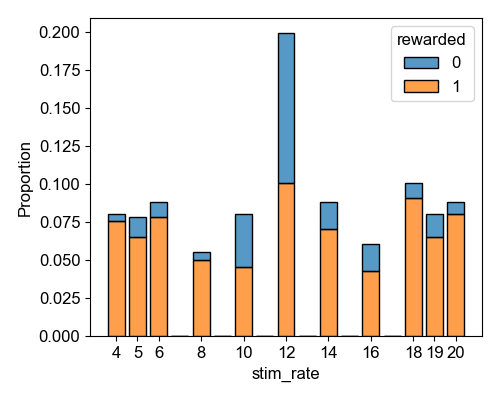

In [9]:
fig, ax = plt.subplots(1, figsize=(5, 4))
sns.histplot(
    data=data,
    x="stim_rate",
    hue="rewarded",
    multiple="stack",
    stat="proportion",
    discrete=True,
    shrink=0.8,
    ax=ax,
)
ax.set_xticks(natsorted(data.stim_rate.unique()))
fig.tight_layout()